# Economy Analysis

This notebook analyzes selected economic indicators from the World Development Indicators dataset.

The analysis focuses on three main economic indicators:

- Gross Domestic Product (GDP)
- GDP Growth
- Inflation

The same selected countries are used throughout the analysis to maintain consistency across the project.

## 1. Load the Dataset

The dataset is downloaded from Kaggle and extracted into the Colab environment.

The main file used in this analysis is the SQLite database:
`database.sqlite`

In [6]:
#!pip install q kaggle
import os
os.environ['KAGGLE_CONFIG_DIR']='/content'

In [7]:
!kaggle datasets download -d kaggle/world-development-indicators

!unzip -q world-development-indicators.zip -d /content/world_development

Dataset URL: https://www.kaggle.com/datasets/kaggle/world-development-indicators
License(s): world-bank
world-development-indicators.zip: Skipping, found more recently modified local copy (use --force to force download)
replace /content/world_development/Country.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


## 2. Import Required Libraries

The analysis uses Python libraries for:

- Connecting to and querying the SQLite database
- Data manipulation and analysis
- Data visualization

In [8]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

## 3. Connect to the Database

The World Development Indicators dataset is stored in a SQLite database.

# A connection is established to access the available tables and retrieve the required economic indicators using SQL queries.

In [9]:
database = '/content/world_development/database.sqlite'

In [10]:
conn = sqlite3.connect(database)

## 4. Explore the Database

Before starting the analysis, the database structure and available indicators are explored.

# This helps identify the relevant tables and confirm the exact indicator names used in the dataset.

In [11]:
tables = pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type = 'table';
""", conn)

tables

,name
0,Country
1,CountryNotes
2,Series
3,Indicators
4,SeriesNotes
5,Footnotes


In [12]:
pd.read_sql("PRAGMA table_info(Indicators);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,CountryName,TEXT,0,None,0
1,1,CountryCode,TEXT,0,None,0
2,2,IndicatorName,TEXT,0,None,0
3,3,IndicatorCode,TEXT,0,None,0
4,4,Year,INTEGER,0,None,0
5,5,Value,NUMERIC,0,None,0


In [13]:
pd.read_sql("SELECT DISTINCT IndicatorName FROM Indicators WHERE IndicatorName LIKE '%GDP%';", conn)

,IndicatorName
0,"2005 PPP conversion factor, GDP (LCU per inter..."
1,"Agriculture, value added (% of GDP)"
2,Broad money (% of GDP)
3,CO2 emissions (kg per 2005 US$ of GDP)
4,CO2 emissions (kg per 2011 PPP $ of GDP)
...,...
81,Tax revenue (% of GDP)
82,Total natural resources rents (% of GDP)
83,Trade (% of GDP)
84,Trade in services (% of GDP)


In [14]:
pd.read_sql("SELECT DISTINCT IndicatorName FROM Indicators WHERE IndicatorName LIKE '%GDP growth%';", conn)

,IndicatorName
0,GDP growth (annual %)


In [15]:
pd.read_sql("SELECT DISTINCT IndicatorName FROM Indicators WHERE IndicatorName LIKE '%Inflation%';", conn)

,IndicatorName
0,"Inflation, GDP deflator (annual %)"
1,"Inflation, consumer prices (annual %)"


In [16]:
pd.read_sql("SELECT DISTINCT CountryName FROM Indicators LIMIT 20;", conn)

,CountryName
0,Afghanistan
1,Albania
2,Algeria
3,American Samoa
4,Andorra
5,Angola
6,Antigua and Barbuda
7,Arab World
8,Argentina
9,Armenia


In [17]:
pd.read_sql("SELECT DISTINCT IndicatorName FROM Indicators WHERE IndicatorName LIKE 'GDP%';", conn)

,IndicatorName
0,GDP (constant LCU)
1,GDP (current LCU)
2,GDP at market prices (constant 2005 US$)
3,GDP at market prices (current US$)
4,GDP deflator (base year varies by country)
5,GDP growth (annual %)
6,GDP per capita (constant 2005 US$)
7,GDP per capita (constant LCU)
8,GDP per capita (current LCU)
9,GDP per capita (current US$)


In [18]:
gdp = pd.read_sql("""
SELECT CountryName, Year, Value
FROM Indicators
WHERE IndicatorName = 'GDP at market prices (current US$)'
AND CountryCode IN (
    'EGY', 'IRN', 'IRQ', 'LBY', 'MAR',
    'SAU', 'TUN', 'ARE', 'WBG', 'YEM', 'SYR'
)""", conn)

gdp.head()

,CountryName,Year,Value
0,"Iran, Islamic Rep.",1960,4.199134e+09
1,Iraq,1960,1.683919e+09
2,Morocco,1960,2.037155e+09
3,Syrian Arab Republic,1960,8.577044e+08
4,"Iran, Islamic Rep.",1961,4.426949e+09


In [19]:
growth = pd.read_sql("""
SELECT CountryName, Year, Value
FROM Indicators
WHERE IndicatorName = 'GDP growth (annual %)'
AND CountryCode IN (
    'EGY', 'IRN', 'IRQ', 'LBY', 'MAR',
    'SAU', 'TUN', 'ARE', 'WBG', 'YEM', 'SYR'
)""", conn)

growth.head()

,CountryName,Year,Value
0,"Iran, Islamic Rep.",1961,10.390918
1,Morocco,1961,-2.425234
2,Syrian Arab Republic,1961,10.833064
3,"Iran, Islamic Rep.",1962,7.909268
4,Morocco,1962,12.517984


In [20]:
inflation = pd.read_sql("""
SELECT CountryName, Year, Value
FROM Indicators
WHERE IndicatorName = 'Inflation, consumer prices (annual %)'
AND CountryCode IN (
    'EGY', 'IRN', 'IRQ', 'LBY', 'MAR',
    'SAU', 'TUN', 'ARE', 'WBG', 'YEM', 'SYR'
)""", conn)

inflation.head()

,CountryName,Year,Value
0,"Egypt, Arab Rep.",1961,0.693607
1,"Iran, Islamic Rep.",1961,3.162564
2,Iraq,1961,0.916260
3,Morocco,1961,1.763125
4,Syrian Arab Republic,1961,1.958891


In [21]:
growth.shape


(440, 3)

In [22]:
growth.groupby("CountryName")["Value"].mean()

,Value
CountryName,
"Egypt, Arab Rep.",4.867722
"Iran, Islamic Rep.",4.376227
Iraq,7.764548
Libya,3.661046
Morocco,4.689455
Saudi Arabia,4.961614
Syrian Arab Republic,5.804991
Tunisia,4.730236
United Arab Emirates,5.102616


In [23]:
growth["CountryName"].unique()

array(['Iran, Islamic Rep.', 'Morocco', 'Syrian Arab Republic',
       'Egypt, Arab Rep.', 'Tunisia', 'Iraq', 'Saudi Arabia',
       'United Arab Emirates', 'Yemen, Rep.', 'West Bank and Gaza',
       'Libya'], dtype=object)

In [24]:
average_growth = growth.groupby("CountryName")["Value"].mean()

average_growth

,Value
CountryName,
"Egypt, Arab Rep.",4.867722
"Iran, Islamic Rep.",4.376227
Iraq,7.764548
Libya,3.661046
Morocco,4.689455
Saudi Arabia,4.961614
Syrian Arab Republic,5.804991
Tunisia,4.730236
United Arab Emirates,5.102616


In [25]:
growth_pivot = growth.pivot(index="Year", columns="CountryName", values="Value")

growth_pivot.head()

CountryName,"Egypt, Arab Rep.","Iran, Islamic Rep.",Iraq,Libya,Morocco,Saudi Arabia,Syrian Arab Republic,Tunisia,United Arab Emirates,West Bank and Gaza,"Yemen, Rep."
Year,,,,,,,,,,,
1961,NaN,10.390918,NaN,NaN,-2.425234,NaN,10.833064,NaN,NaN,NaN,NaN
1962,NaN,7.909268,NaN,NaN,12.517984,NaN,24.521297,NaN,NaN,NaN,NaN
1963,NaN,7.042075,NaN,NaN,4.863604,NaN,-8.652747,NaN,NaN,NaN,NaN
1964,NaN,8.475228,NaN,NaN,1.286363,NaN,9.271364,NaN,NaN,NaN,NaN
1965,NaN,17.035712,NaN,NaN,NaN,NaN,2.299374,NaN,NaN,NaN,NaN


In [26]:
growth.groupby("CountryName")["Year"].max()

,Year
CountryName,
"Egypt, Arab Rep.",2014
"Iran, Islamic Rep.",2014
Iraq,2014
Libya,2014
Morocco,2014
Saudi Arabia,2014
Syrian Arab Republic,2007
Tunisia,2014
United Arab Emirates,2014


In [27]:
growth.groupby("CountryName")["Year"].count()

,Year
CountryName,
"Egypt, Arab Rep.",49
"Iran, Islamic Rep.",54
Iraq,46
Libya,15
Morocco,52
Saudi Arabia,46
Syrian Arab Republic,47
Tunisia,49
United Arab Emirates,39


In [28]:
growth.groupby("CountryName")["Value"].agg(["min", "max"])

,min,max
CountryName,,
"Egypt, Arab Rep.",0.625935,14.627248
"Iran, Islamic Rep.",-21.599649,23.171246
Iraq,-64.047107,57.817828
Libya,-62.075920,104.486789
Morocco,-6.328695,13.459779
Saudi Arabia,-10.426810,22.672523
Syrian Arab Republic,-8.958214,25.027607
Tunisia,-1.917624,17.742718
United Arab Emirates,-14.958137,23.874775


In [29]:
growth = growth.sort_values("Year")

growth.head()

,CountryName,Year,Value
0,"Iran, Islamic Rep.",1961,10.390918
1,Morocco,1961,-2.425234
2,Syrian Arab Republic,1961,10.833064
3,"Iran, Islamic Rep.",1962,7.909268
4,Morocco,1962,12.517984


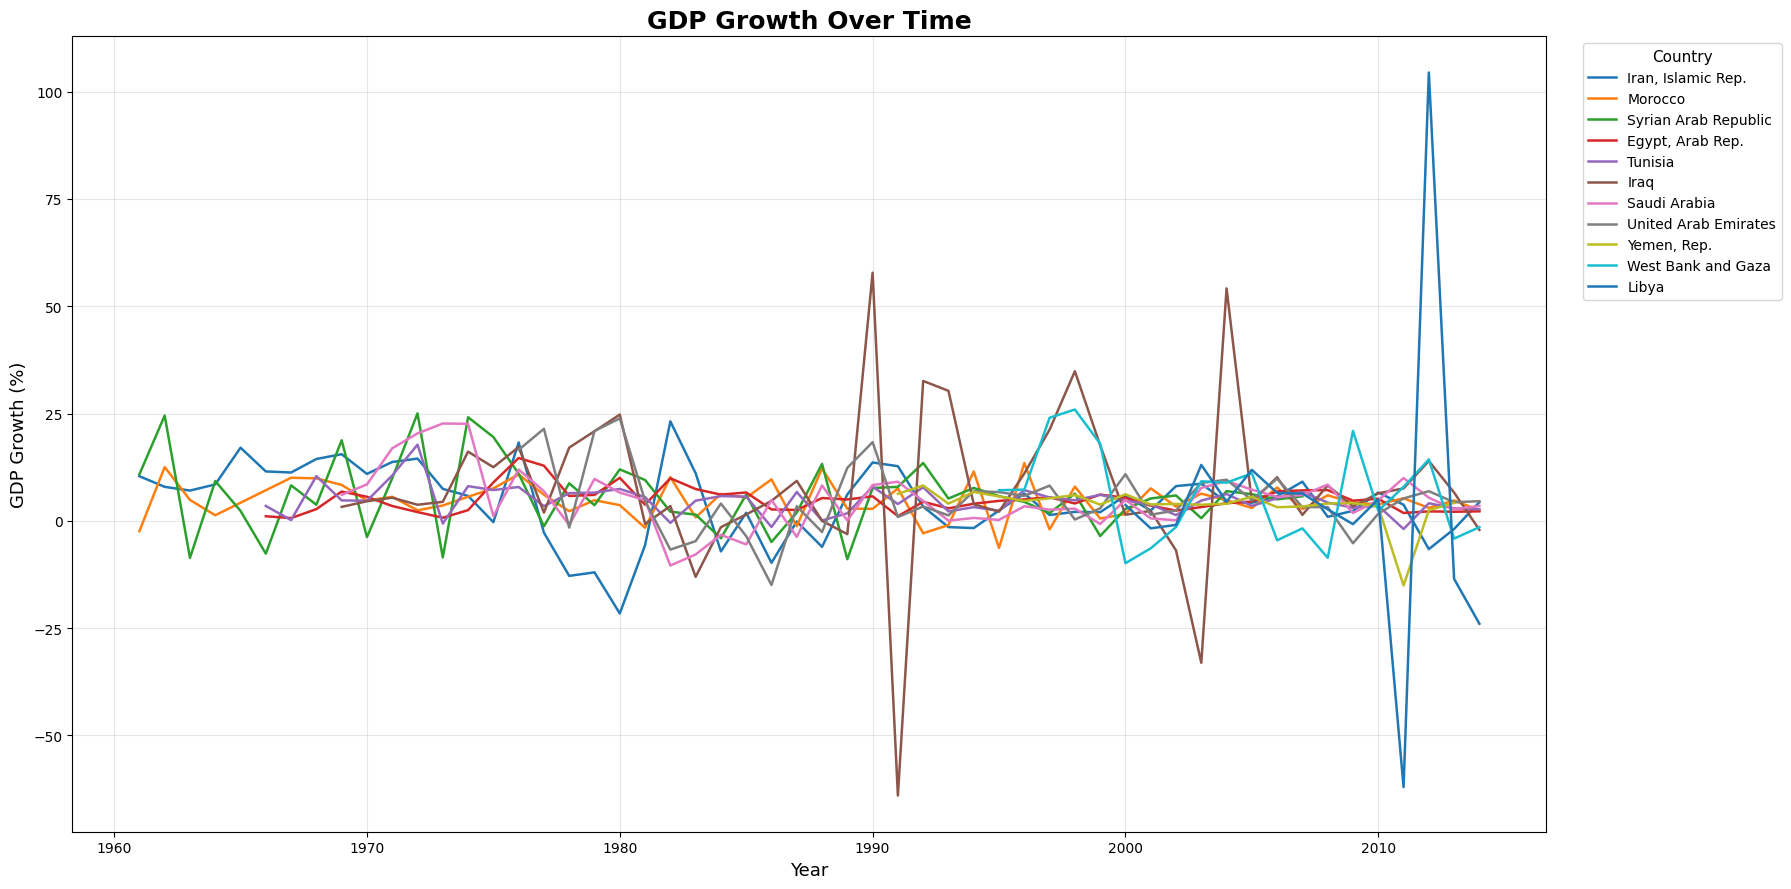

In [33]:
plt.figure(figsize=(18, 9))

for country in growth["CountryName"].unique():
    country_data = growth[growth["CountryName"] == country]

    plt.plot(
        country_data["Year"],
        country_data["Value"],
        label=country,
        linewidth=1.8
    )

plt.xlabel("Year", fontsize=13)
plt.ylabel("GDP Growth (%)", fontsize=13)

plt.title(
    "GDP Growth Over Time",
    fontsize=18,
    fontweight="bold"
)

plt.grid(True, alpha=0.3)

plt.legend(
    title="Country",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout()
plt.show()

In [34]:
gdp["Year"].max()

2014

In [35]:
gdp_2014 = gdp[gdp["Year"] == 2014]

gdp_2014

,CountryName,Year,Value
443,"Egypt, Arab Rep.",2014,2.865380e+11
444,"Iran, Islamic Rep.",2014,4.253261e+11
445,Iraq,2014,2.235081e+11
446,Libya,2014,4.114272e+10
447,Morocco,2014,1.100090e+11
448,Saudi Arabia,2014,7.462485e+11
449,Tunisia,2014,4.861265e+10
450,United Arab Emirates,2014,3.994513e+11
451,West Bank and Gaza,2014,1.273761e+10


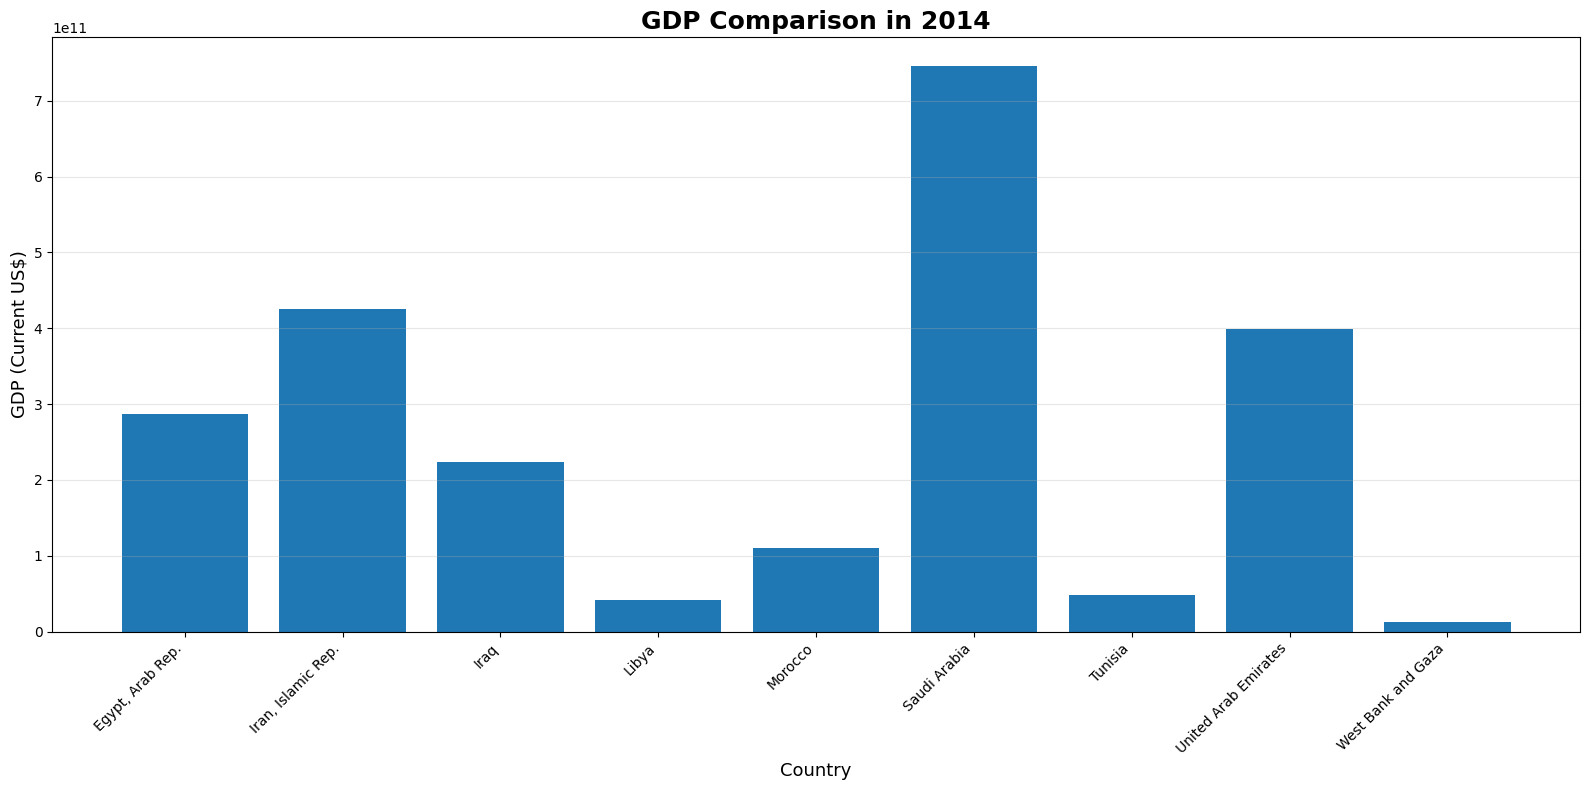

In [39]:
plt.figure(figsize=(16, 8))

plt.bar(
    gdp_2014["CountryName"],
    gdp_2014["Value"]
)

plt.xlabel("Country", fontsize=13)
plt.ylabel("GDP (Current US$)", fontsize=13)

plt.title(
    "GDP Comparison in 2014",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=10
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [ ]:
inflation.groupby("CountryName")["Value"].mean()

CountryName
China            3.162222
Germany          1.841345
United States    3.962124
Name: Value, dtype: float64

In [ ]:
inflation = inflation.sort_values("Year")

inflation.head()

,CountryName,Year,Value
0,United States,1961,1.075182
1,United States,1962,1.116071
2,United States,1963,1.214128
3,United States,1964,1.308615
4,United States,1965,1.668461


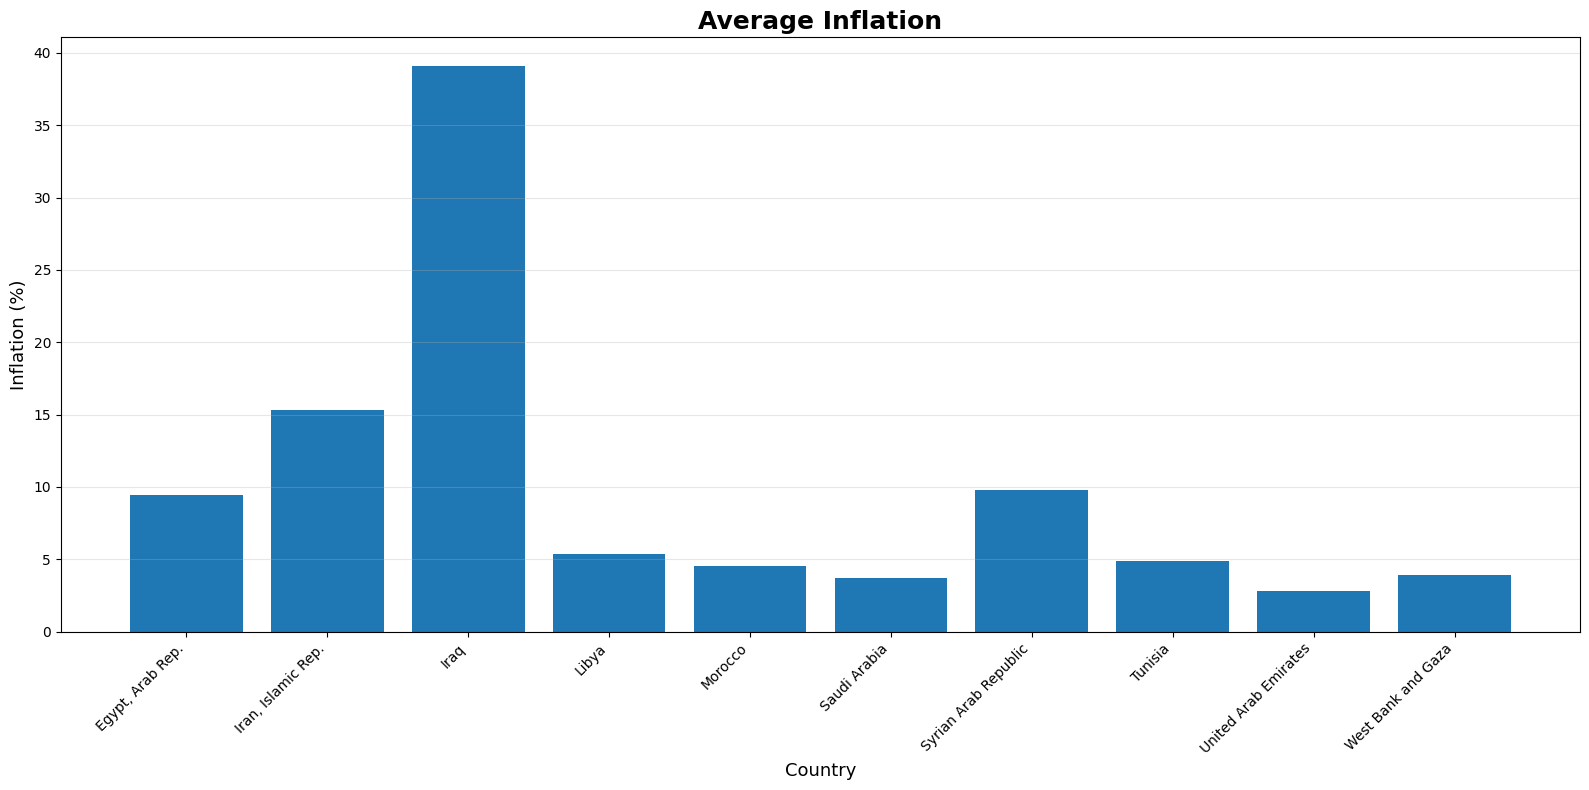

In [42]:
average_inflation = inflation.groupby("CountryName")["Value"].mean()

plt.figure(figsize=(16, 8))

plt.bar(
    average_inflation.index,
    average_inflation.values
)

plt.xlabel("Country", fontsize=13)
plt.ylabel("Inflation (%)", fontsize=13)

plt.title(
    "Average Inflation",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(
    rotation=45,
    ha="right",
    fontsize=10
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

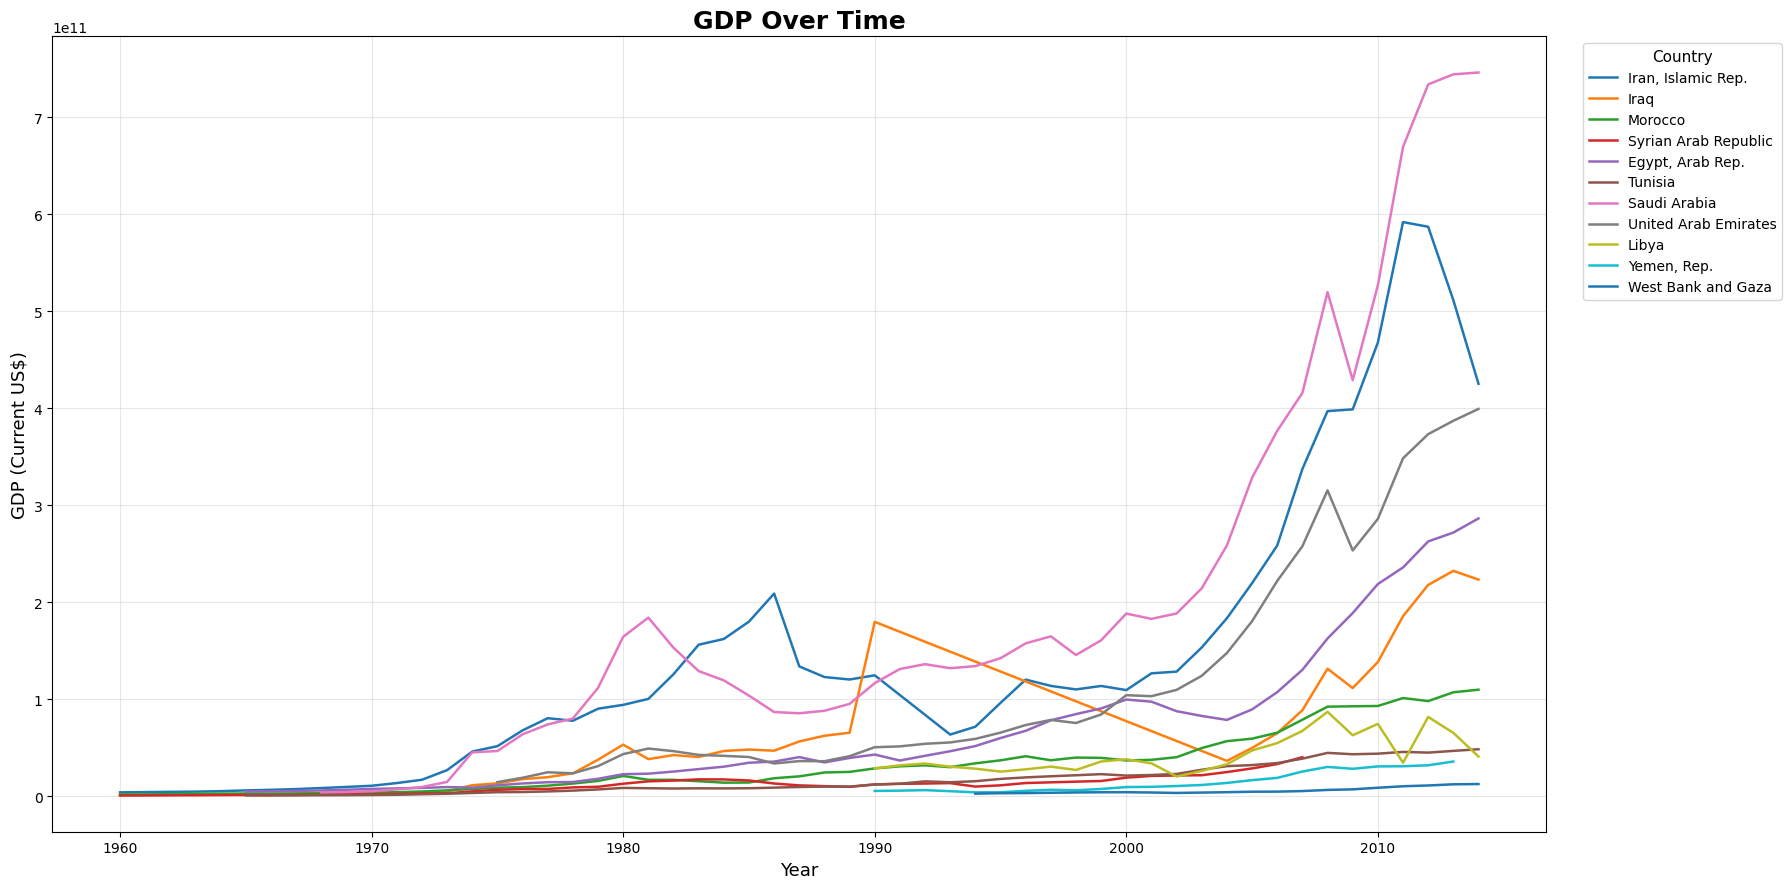

In [44]:
plt.figure(figsize=(18, 9))

for country in gdp["CountryName"].unique():
    country_data = gdp[gdp["CountryName"] == country]

    plt.plot(
        country_data["Year"],
        country_data["Value"],
        label=country,
        linewidth=1.8
    )

plt.xlabel("Year", fontsize=13)
plt.ylabel("GDP (Current US$)", fontsize=13)

plt.title(
    "GDP Over Time",
    fontsize=18,
    fontweight="bold"
)

plt.grid(True, alpha=0.3)

plt.legend(
    title="Country",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout()
plt.show()